# CharRNN Final Project - Complete Pipeline

Character-level language model using RNN/LSTM/GRU with comprehensive hyperparameter experiments.

Based on [spro/char-rnn.pytorch](https://github.com/spro/char-rnn.pytorch) with improvements:
- Added vanilla RNN support for three-way comparison
- Dropout regularization
- Validation split & perplexity tracking
- Automated experiment grid
- Publication-ready visualization


## 0. Setup

In [1]:
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')

PyTorch version: 2.2.1+cu121
CUDA available: True
GPU: NVIDIA A30
Using: cuda


## 1. Load Dataset

In [5]:
from data_utils import TextDataset, download_shakespeare, download_sherlock

# Primary dataset: Tiny Shakespeare
shakespeare_path = download_shakespeare()
dataset_shakespeare = TextDataset(shakespeare_path, val_fraction=0.1)

# Preview
print(f'\nFirst 500 characters:\n')
print(dataset_shakespeare.raw_text[:500])

Already exists: data/shakespeare.txt
Dataset: 1115394 chars, 65 unique
Train: 1003854 chars, Val: 111540 chars

First 500 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## 2. Quick Sanity Check 
Train 3 small models (RNN, LSTM, GRU) briefly to verify everything works.

In [5]:
from run_experiments import get_quick_test_experiments, run_experiment_grid

quick_exps = get_quick_test_experiments(n_epochs=500, print_every=100)
quick_results = run_experiment_grid(dataset_shakespeare, quick_exps, save_dir='results_quick')


Experiment 1/3: quick_rnn
Config: model=rnn, hidden=128, layers=1, lr=0.002, dropout=0.0, opt=adam
Using device: cuda
Model parameters: 49,729
[1/500] (2s) train_loss=4.1727 val_loss=4.0271 val_ppl=56.10
  Sample: The HHW,ZXAKPSGCjoWdFUe-'.kViT
ggaxzggN
nINGtqeKvVYLXofXtwyKIdMGLLM'oHKZoINQ&I:y...
[100/500] (20s) train_loss=2.1514 val_loss=2.1660 val_ppl=8.72
  Sample: The and lithe nom thes welly fare foorf trreaken:
Yo fore thou pimene will thilu...
[200/500] (40s) train_loss=1.9524 val_loss=2.0258 val_ppl=7.58
  Sample: The hancoussagher made fare is the darkering and the dole cain the with Cith hop...
[300/500] (59s) train_loss=1.8529 val_loss=1.9419 val_ppl=6.97
  Sample: The her even heare, and be hearn had of here,
Wh that shought the shall saioust ...
[400/500] (78s) train_loss=1.8190 val_loss=1.9146 val_ppl=6.78
  Sample: The hush for us we shiloves that anl hord.

LEONTERR ALAPUS:

LORK::
So so up th...
[500/500] (97s) train_loss=1.7946 val_loss=1.8884 val_ppl=6.61
  Sample: 

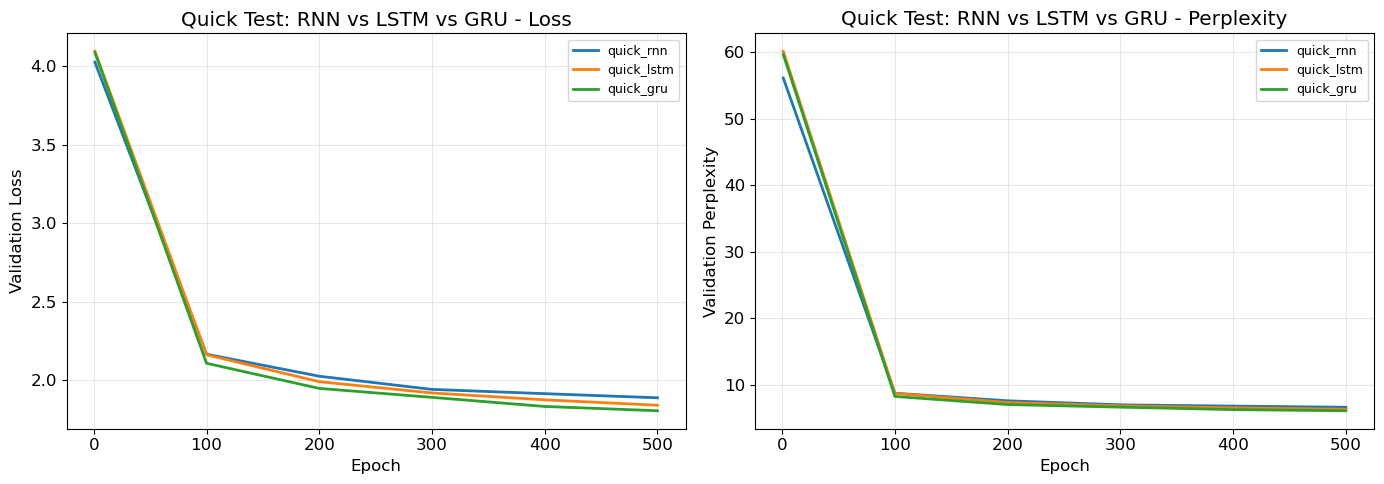

In [6]:
from visualize import plot_group_comparison
plot_group_comparison(quick_results, 'quick_', title='Quick Test: RNN vs LSTM vs GRU')

## 3. Full Experiment Grid 

- Model type: RNN vs LSTM vs GRU
- Hidden size: 128, 256, 512
- Number of layers: 1, 2, 3
- Learning rate: 0.0005, 0.001, 0.002, 0.005
- Optimizer: Adam, SGD, RMSProp
- Dropout: 0.0, 0.2, 0.5
- Sequence length: 100, 200, 300

In [8]:
from run_experiments import get_core_experiments

core_exps = get_core_experiments(n_epochs=2000, print_every=200)
results = run_experiment_grid(dataset_shakespeare, core_exps, save_dir='results')

Total unique experiments: 16

Experiment 1/16: model_rnn
Config: model=rnn, hidden=256, layers=2, lr=0.002, dropout=0.2, opt=adam
Using device: cuda
Model parameters: 296,513
[1/2000] (1s) train_loss=4.1925 val_loss=3.8236 val_ppl=45.77
  Sample: The wnrs' oD3N;mz-zs:m'o:hKw?&
3yovKvWK
mORJ&Lpe3SN:.bdaiTiHjW!mYGDW:Gtoamzkjgcu...
[200/2000] (45s) train_loss=1.8198 val_loss=1.8639 val_ppl=6.45
  Sample: The strest, out good and with shall scare and have again a me him!

PENIUS:
Prot...
[400/2000] (90s) train_loss=1.7295 val_loss=1.7697 val_ppl=5.87
  Sample: The how friend.

VIOR
A pliod your more now father chean see for come in marry a...
[600/2000] (135s) train_loss=1.7185 val_loss=1.7211 val_ppl=5.59
  Sample: The me on shall both this death!
The liet.

CAMILLO:
O as of his says the man we...
[800/2000] (179s) train_loss=1.6509 val_loss=1.6893 val_ppl=5.42
  Sample: The were the worst debund by on joyss, and by the audart all this cent?

CORIOLA...
[1000/2000] (224s) train_loss=1.648

## 4. Generate All Plots

In [9]:
import shutil
shutil.make_archive('all_results', 'zip', '.', 'results')
print("Done! Download all_results.zip from the file browser.")

Done! Download all_results.zip from the file browser.


Saved: figures/model_comparison.png


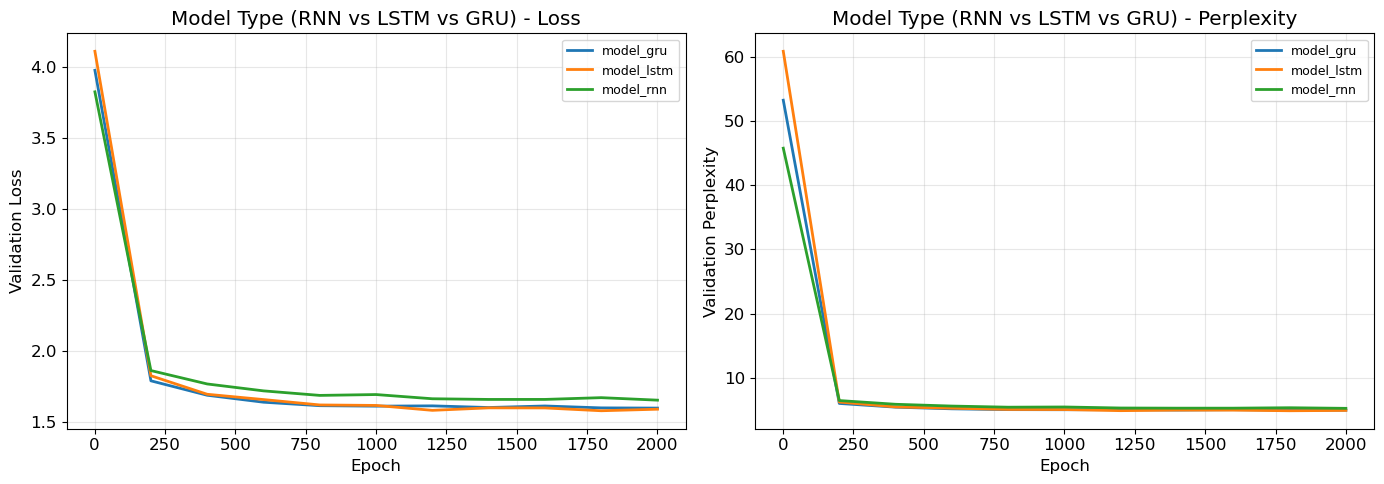

Saved: figures/hidden_size.png


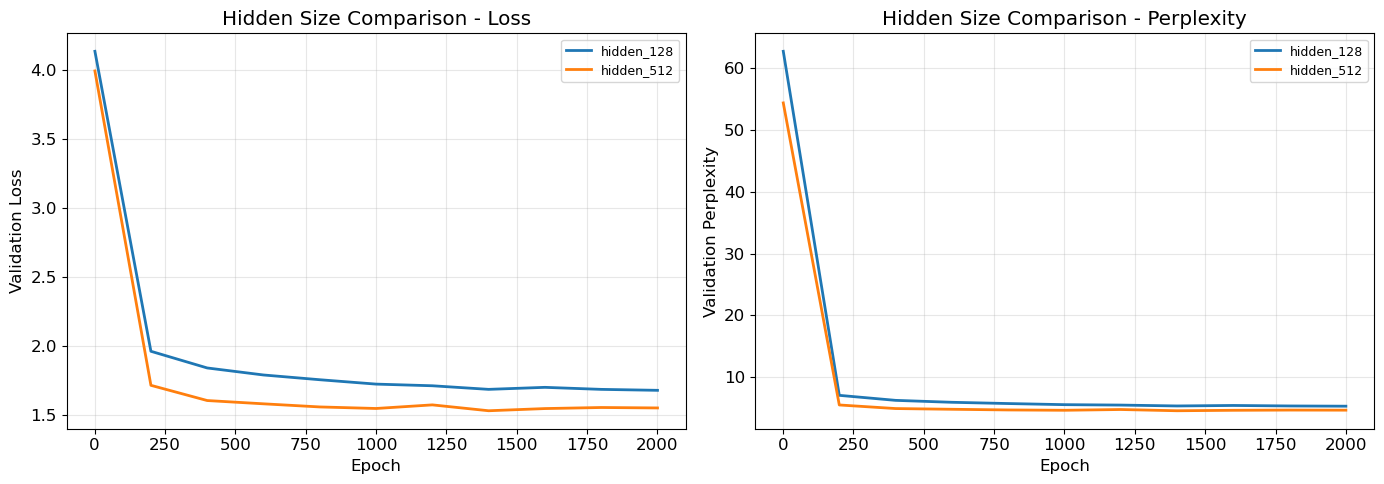

Saved: figures/layers.png


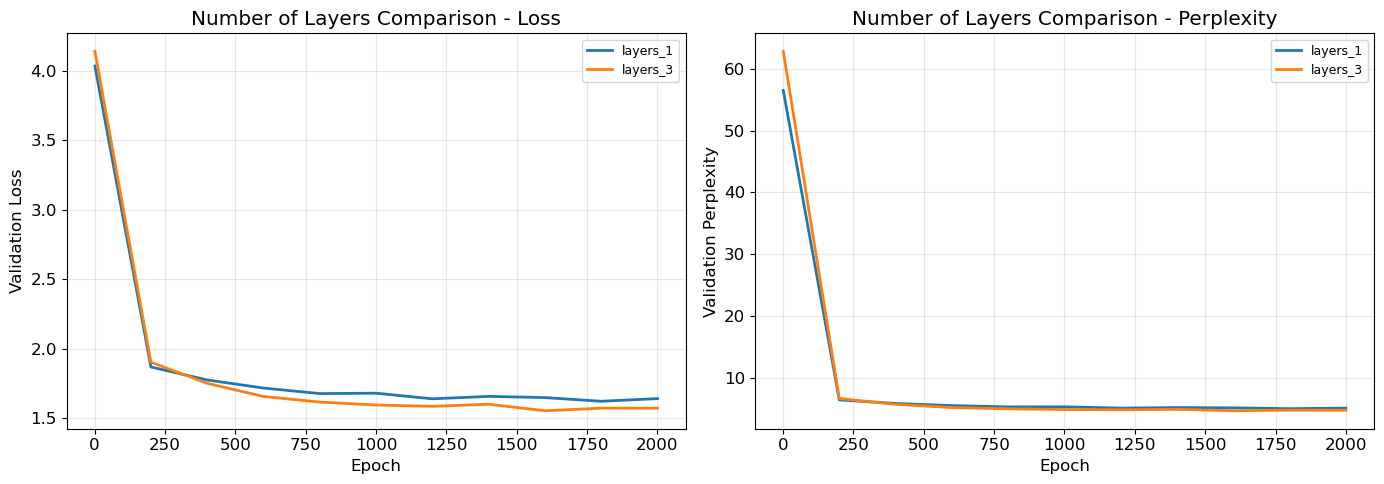

Saved: figures/learning_rate.png


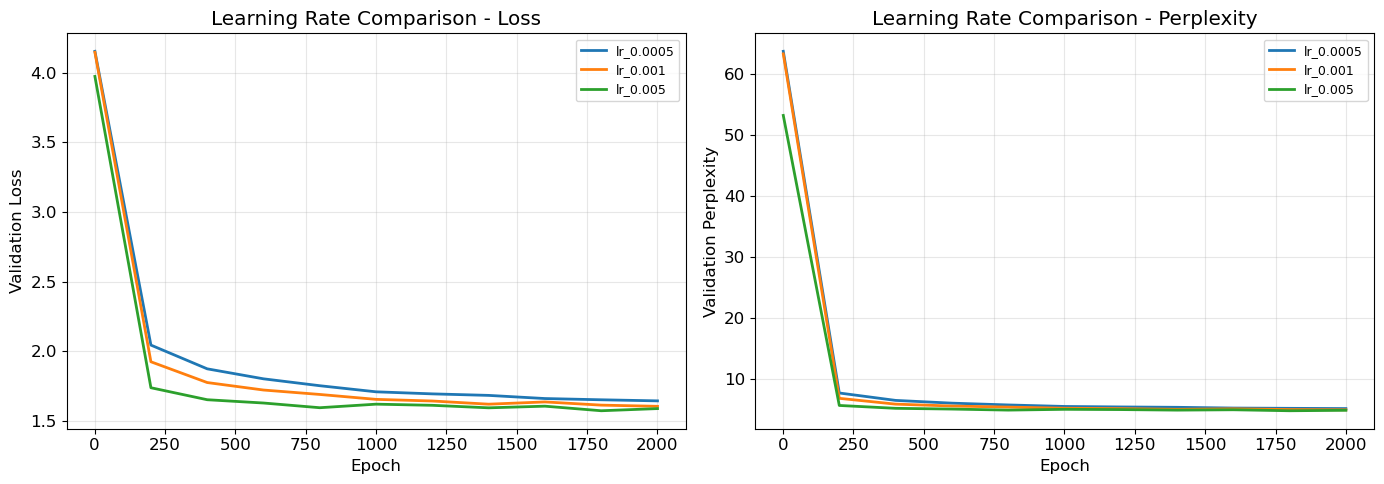

Saved: figures/optimizer.png


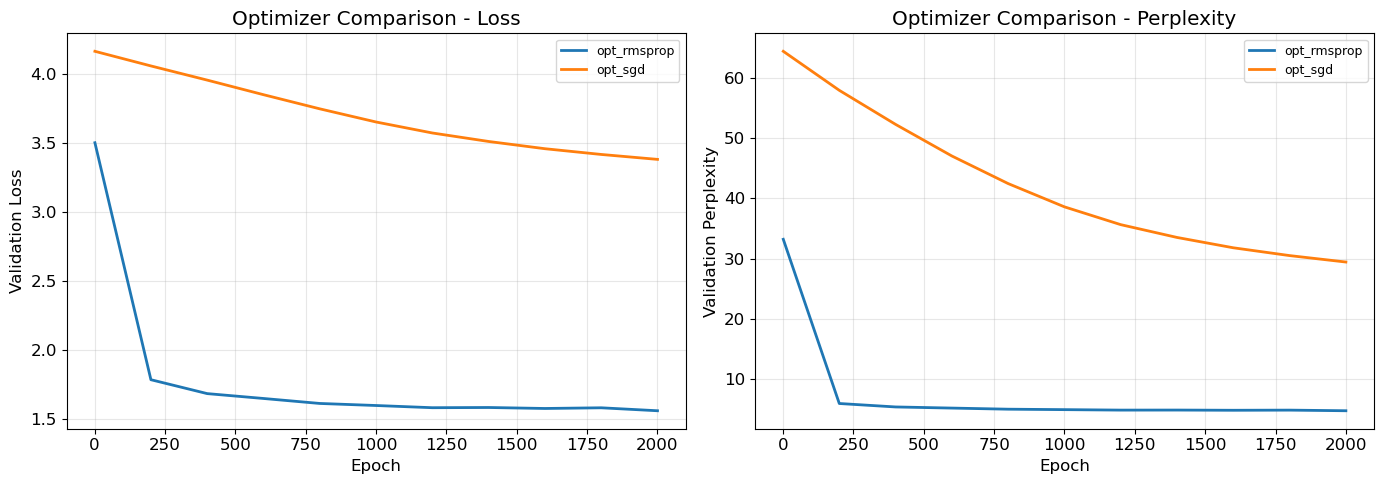

Saved: figures/dropout.png


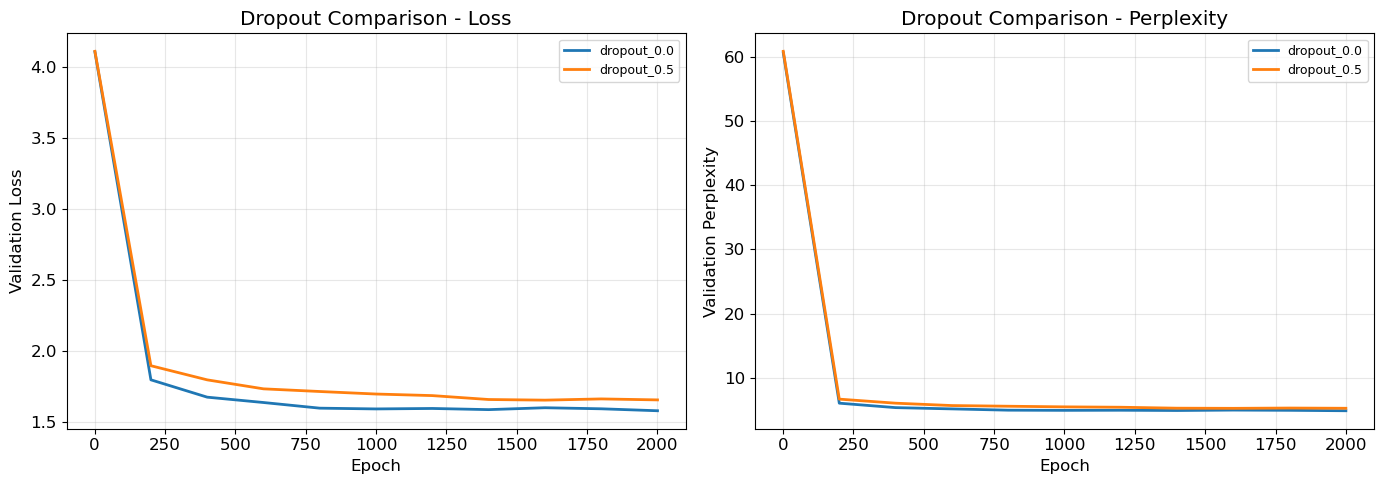

Saved: figures/chunk_length.png


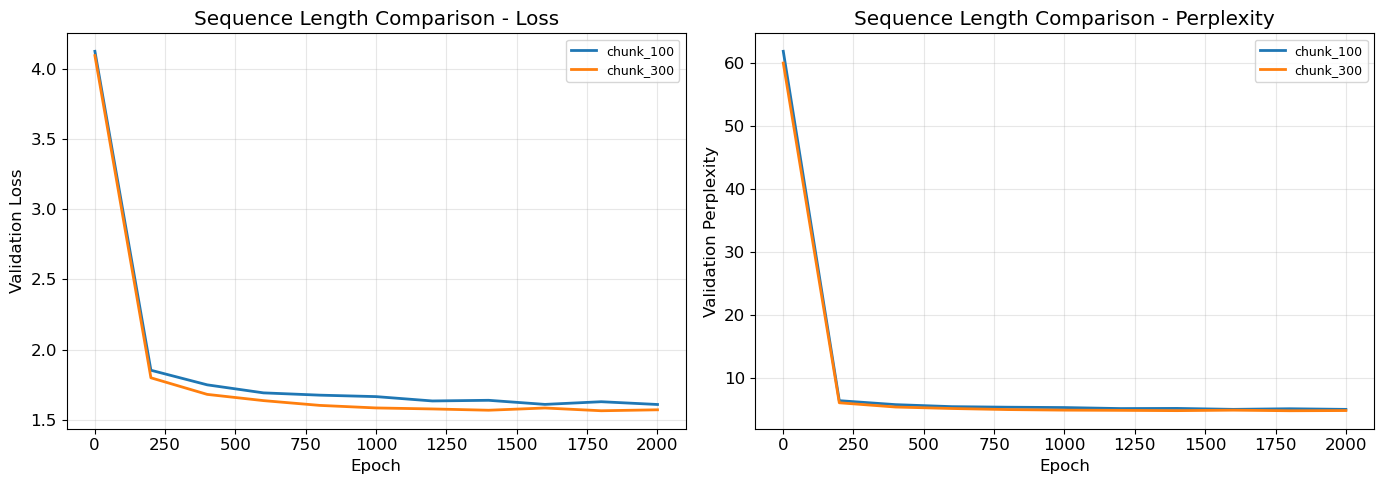

Saved: figures/summary_ppl.png


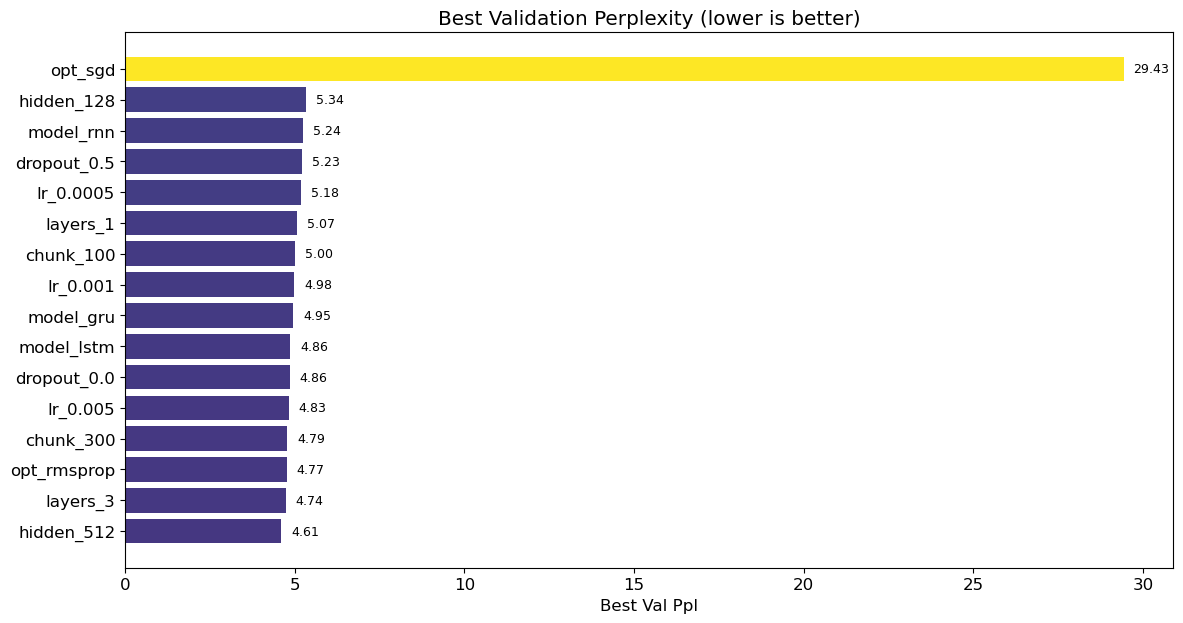

Saved: figures/summary_loss.png


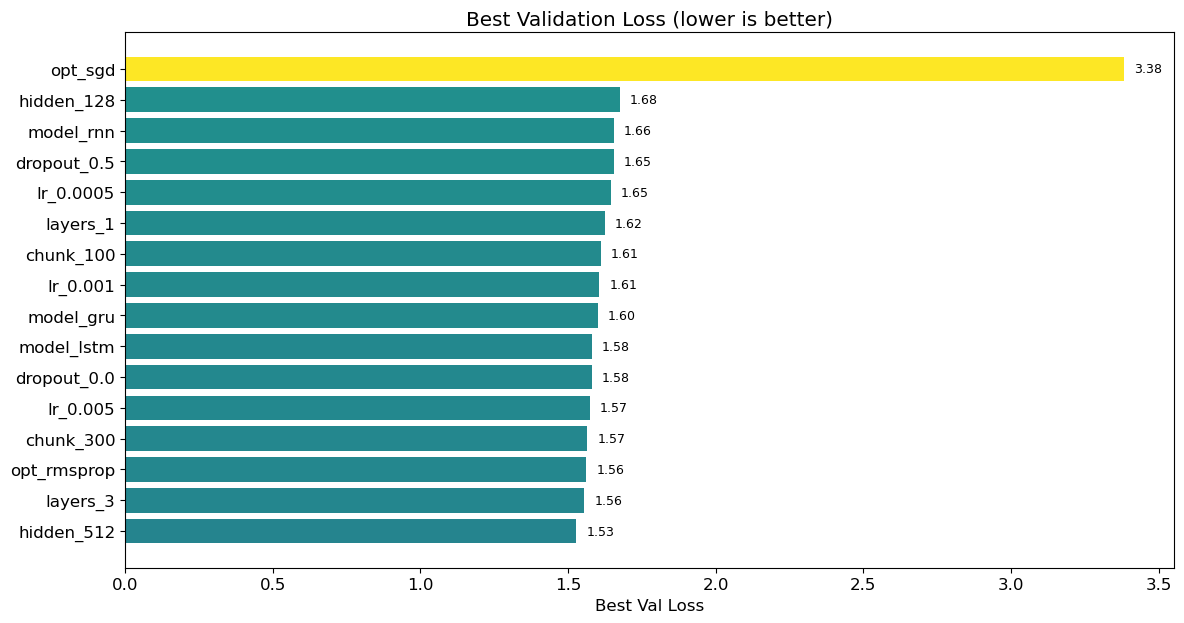

Saved: figures/training_time.png


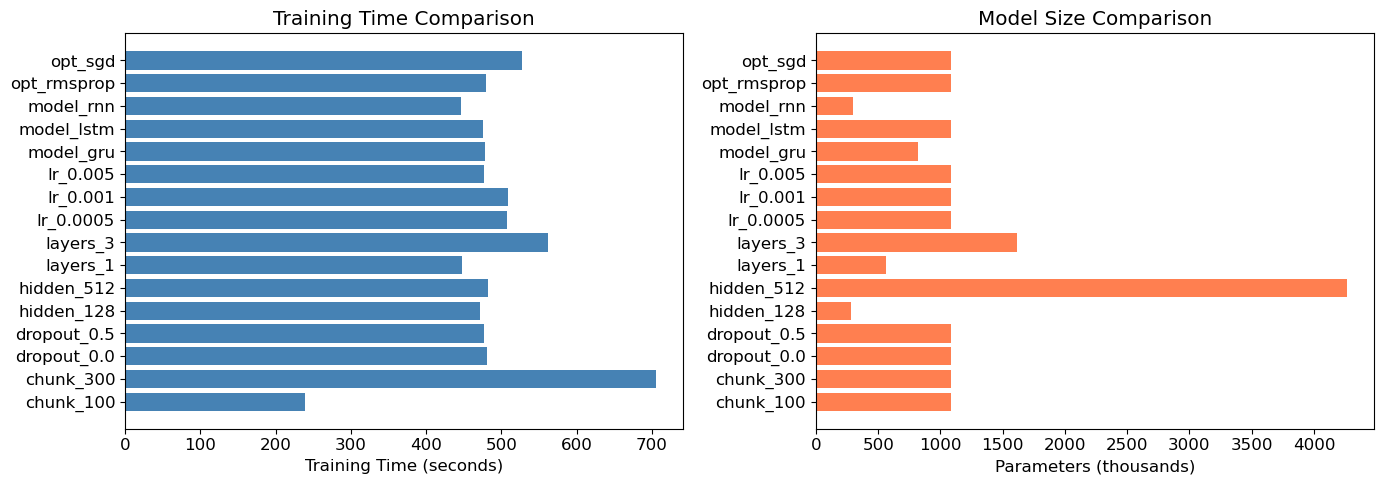


All figures saved to figures/


In [11]:
from visualize import generate_all_plots
generate_all_plots(results, save_dir='figures')

## 5. Temperature Comparison 
Load the best model and generate text at different temperatures.

In [5]:
from model import CharRNN
from generate import generate_text, generate_samples_at_temperatures
from visualize import plot_temperature_samples

# Find best model
valid_results = [r for r in results if 'error' not in r]
best = min(valid_results, key=lambda r: r['best_val_loss'])
print(f'Best model: {best["name"]} (val_loss={best["best_val_loss"]:.4f}, ppl={best["best_val_ppl"]:.2f})')

best['config']['save_path'] = f"results/{best['name']}.pt"
# Load model
checkpoint = torch.load(best['config']['save_path'], map_location=device, weights_only=False)
model = CharRNN(
    input_size=dataset_shakespeare.n_characters,
    hidden_size=best['config']['hidden_size'],
    output_size=dataset_shakespeare.n_characters,
    model_type=best['config']['model_type'],
    n_layers=best['config']['n_layers'],
    dropout=best['config'].get('dropout', 0.0)
).to(device)
model.load_state_dict(checkpoint['model_state'])

NameError: name 'results' is not defined

## 6. Generate Shakespeare-style Text

In [14]:
# Generate at different temperatures
samples = generate_samples_at_temperatures(
    model, dataset_shakespeare, device,
    prime_str='ROMEO: ',
    predict_len=500,
    temperatures=[0.2, 0.5, 0.8, 1.0, 1.5]
)
plot_temperature_samples(samples, save_path='figures/temperature_samples.txt')

TEXT SAMPLES AT DIFFERENT TEMPERATURES

--- Temperature = 0.2 ---
ROMEO: I have see the state of the house of the stay the world the sun to the world the contract the world the prince the sent the common men and the prince the heart is the prince and the sense of the world the prince the prince and the sense of the dead to the sense to the world and many the common men and the senator:
The gods the thing in the most a presence the sense of the people of the house of the sense to the world the dead in the season to the people of your honour to the fire of the fire and

--- Temperature = 0.5 ---
ROMEO: what says all the fools and his deadly so much as if the world with the like a thousand him to his life of a poor how the best of me.

CORIOLANUS:
Come, on my lord, to the first have in the poor cousin, when they think you in this content
Than the first be as hand.

CORIOLANUS:
That I hear the consent of a life,
And for the world, which in this be the parting that the prove a further the h

## 6. Second Dataset: Sherlock Holmes (Cross-dataset Comparison)
Run the core model comparison on a second dataset for the report.

In [6]:
# Download and load
sherlock_path = download_sherlock()
dataset_sherlock = TextDataset(sherlock_path, val_fraction=0.1)

Already exists: data/sherlock.txt
Dataset: 3381928 chars, 97 unique
Train: 3043735 chars, Val: 338193 chars


Total unique experiments: 16

Experiment 1/3: model_rnn_sherlock
Config: model=rnn, hidden=256, layers=2, lr=0.002, dropout=0.2, opt=adam
Using device: cuda
Model parameters: 312,929
[1/2000] (0s) train_loss=4.6069 val_loss=4.1086 val_ppl=60.86
  Sample: The   hâ£lx;âz2k?BXX&Kk0lpyYGHBqKFq1kûè½I9z)1EriU½ECH,°3&z!MGhC0QGY:&ur8OqT."[dv...
[200/2000] (1s) train_loss=1.6482 val_loss=1.5752 val_ppl=4.83
  Sample: The case my orsted tarned for his tan kneck with
     net has comparter to the f...
[400/2000] (2s) train_loss=1.5165 val_loss=1.4541 val_ppl=4.28
  Sample: The was
     for a little wrated door and a down a down the time in the should d...
[600/2000] (3s) train_loss=1.4878 val_loss=1.4112 val_ppl=4.10
  Sample: The would be are my upon
     exportant to all had happen in Mr. Sherlock Masker...
[800/2000] (4s) train_loss=1.3853 val_loss=1.3678 val_ppl=3.93
  Sample: The words, is the popitience nuthard has been brought his matter was a are the s...
[1000/2000] (5s) train_loss=1.409

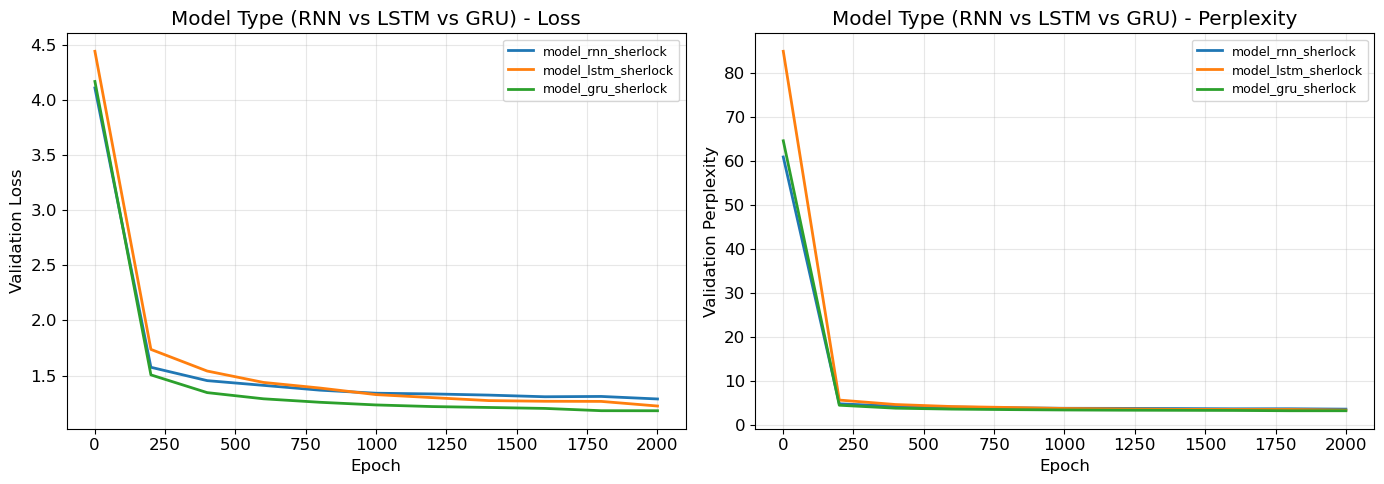

Saved: figures_sherlock/summary_ppl.png


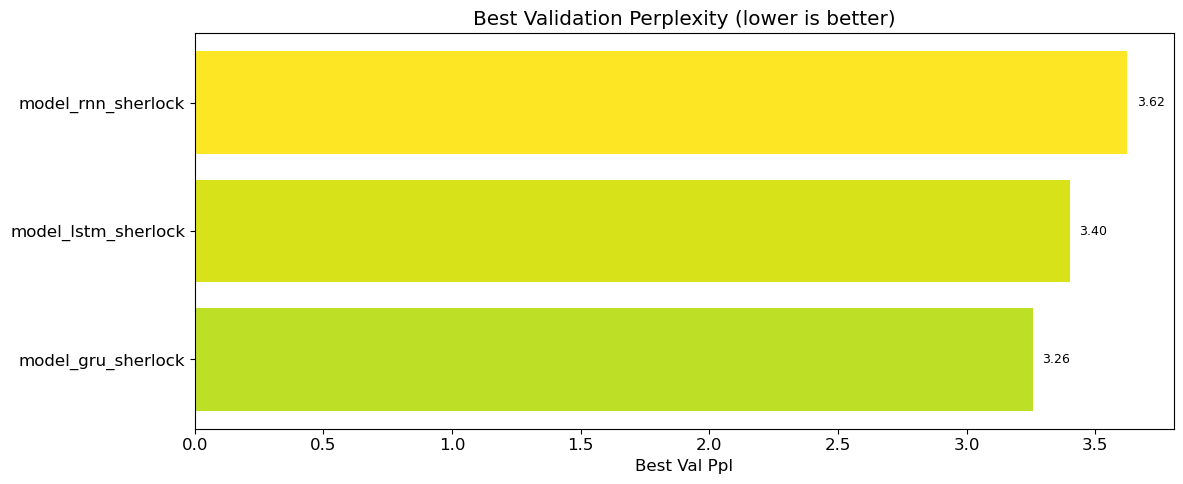

Saved: figures_sherlock/summary_loss.png


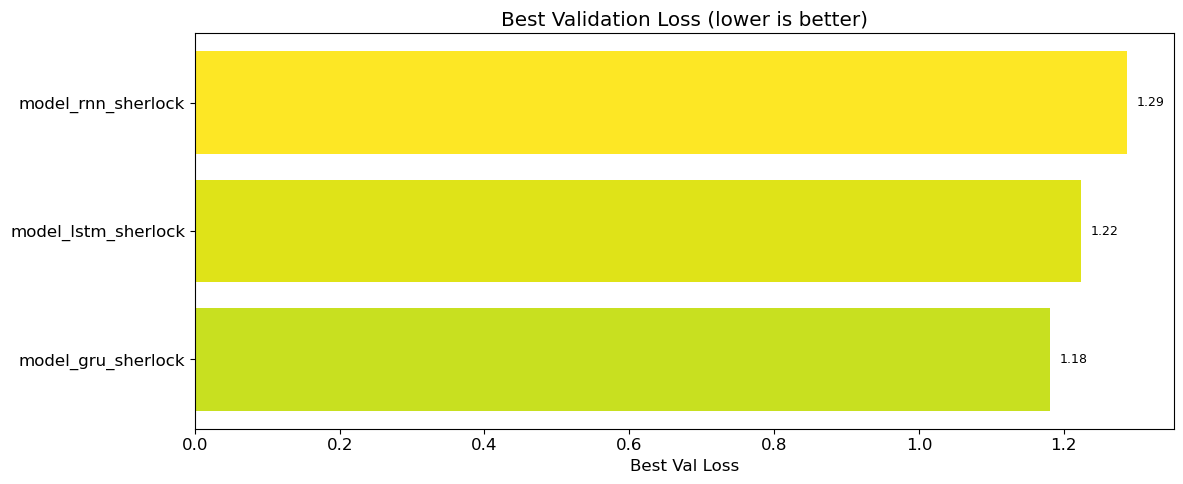

Saved: figures_sherlock/training_time.png


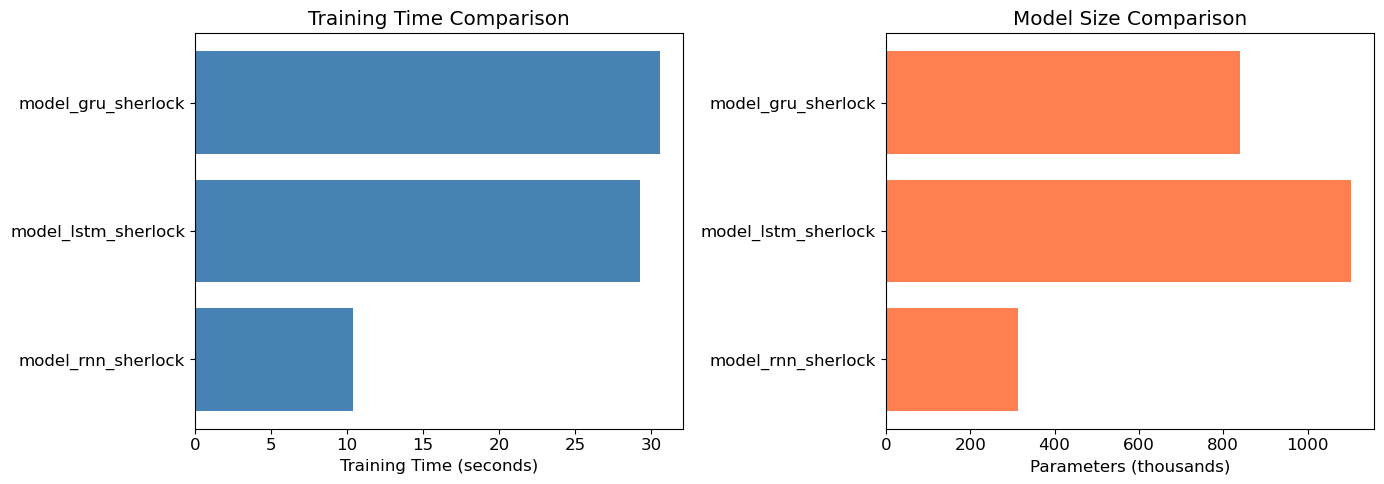


All figures saved to figures_sherlock/


In [8]:
# Run model type comparison on Sherlock Holmes
from visualize import generate_all_plots
from run_experiments import get_core_experiments, run_experiment_grid
sherlock_exps = [e for e in get_core_experiments(n_epochs=2000, print_every=200)
                 if e['name'].startswith('model_')]

# Update save paths
for e in sherlock_exps:
    e['name'] = e['name'] + '_sherlock'

results_sherlock = run_experiment_grid(dataset_sherlock, sherlock_exps, save_dir='results_sherlock')
generate_all_plots(results_sherlock, save_dir='figures_sherlock')

## 7. Generate Sherlock-style Text

In [11]:
from model import CharRNN
from generate import generate_samples_at_temperatures
from visualize import plot_temperature_samples

# Find best Sherlock model
valid_sh = [r for r in results_sherlock if 'error' not in r]
best_sh = min(valid_sh, key=lambda r: r['best_val_loss'])

checkpoint_sh = torch.load(best_sh['config']['save_path'], map_location=device, weights_only=False)
model_sh = CharRNN(
    input_size=dataset_sherlock.n_characters,
    hidden_size=best_sh['config']['hidden_size'],
    output_size=dataset_sherlock.n_characters,
    model_type=best_sh['config']['model_type'],
    n_layers=best_sh['config']['n_layers'],
    dropout=best_sh['config'].get('dropout', 0.0)
).to(device)
model_sh.load_state_dict(checkpoint_sh['model_state'])

samples_sh = generate_samples_at_temperatures(
    model_sh, dataset_sherlock, device,
    prime_str='Holmes ',
    predict_len=500,
    temperatures=[0.2, 0.5, 0.8, 1.0, 1.5]
)
plot_temperature_samples(samples_sh, save_path='figures_sherlock/temperature_samples.txt')

TEXT SAMPLES AT DIFFERENT TEMPERATURES

--- Temperature = 0.2 ---
Holmes was a statement of the street. The
     constable had been the street of the constable which was a strange and
     perfectly hand and the street. I had not seen the door of the constable
     which had been the street of the contrary, and the street was a strange
     constable which was the street of the constable which had been the
     confession of the constable which had been the constable which had
     been the statement of the corner of the constable which had been the
     facts of the

--- Temperature = 0.5 ---
Holmes was the corner of the constable of the
     constation of the longer. It was the front of the case and the house behind
     the grim man of the shilling of the room. They were starting up at his
     lady was on the college of the police had been some time and perhaps
     they were with the house of the constable of the room. It is my and
     the other case with his feet the distance of

## 8. Export Summary Table (for Report)
Print a formatted table you can paste into your report.

In [13]:
import json, os

results = []
for f in sorted(os.listdir('results')):
    if f.endswith('_result.json'):
        with open(os.path.join('results', f)) as fh:
            results.append(json.load(fh))

print(f"Loaded {len(results)} Shakespeare experiment results")

Loaded 16 Shakespeare experiment results


In [14]:
import json

print('\n' + '='*90)
print(f'{"Experiment":<25} {"Model":<8} {"Hidden":<8} {"Layers":<8} {"LR":<10} {"Val Loss":<10} {"Val PPL":<10} {"Time(s)":<10}')
print('-'*90)

sorted_results = sorted(
    [r for r in results if 'error' not in r],
    key=lambda r: r['best_val_loss']
)

for r in sorted_results:
    c = r['config']
    print(f'{r["name"]:<25} {c["model_type"]:<8} {c["hidden_size"]:<8} {c["n_layers"]:<8} '
          f'{c["learning_rate"]:<10} {r["best_val_loss"]:<10.4f} {r["best_val_ppl"]:<10.2f} {r["total_time"]:<10.1f}')

print('='*90)


Experiment                Model    Hidden   Layers   LR         Val Loss   Val PPL    Time(s)   
------------------------------------------------------------------------------------------
hidden_512                lstm     512      2        0.002      1.5276     4.61       482.5     
layers_3                  lstm     256      3        0.002      1.5552     4.74       562.1     
opt_rmsprop               lstm     256      2        0.002      1.5613     4.77       479.2     
chunk_300                 lstm     256      2        0.002      1.5657     4.79       706.1     
lr_0.005                  lstm     256      2        0.005      1.5743     4.83       477.7     
dropout_0.0               lstm     256      2        0.002      1.5801     4.86       480.5     
model_lstm                lstm     256      2        0.002      1.5813     4.86       475.3     
model_gru                 gru      256      2        0.002      1.6000     4.95       477.8     
lr_0.001                  lstm     

## 9. Download All Results
Zip everything for download.

In [15]:
import shutil
shutil.make_archive('charRNN_results', 'zip', '.', 'figures')
shutil.make_archive('charRNN_results_sherlock', 'zip', '.', 'figures_sherlock')
print('Download: charRNN_results.zip and charRNN_results_sherlock.zip')

Download: charRNN_results.zip and charRNN_results_sherlock.zip


In [2]:
import torch
from data_utils import TextDataset, download_shakespeare, download_sherlock
from model import CharRNN
from generate import generate_text, generate_samples_at_temperatures
from run_experiments import get_core_experiments, run_experiment_grid
from visualize import generate_all_plots, plot_temperature_samples
import json, os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


dataset_shakespeare = TextDataset(download_shakespeare(), val_fraction=0.1)
dataset_sherlock = TextDataset(download_sherlock(), val_fraction=0.1)


results = []
for f in sorted(os.listdir('results')):
    if f.endswith('_result.json'):
        with open(os.path.join('results', f)) as fh:
            results.append(json.load(fh))

results_sherlock = []
for f in sorted(os.listdir('results_sherlock')):
    if f.endswith('_result.json'):
        with open(os.path.join('results_sherlock', f)) as fh:
            results_sherlock.append(json.load(fh))

print(f"Loaded: {len(results)} Shakespeare + {len(results_sherlock)} Sherlock results")
print("Ready for new experiments!")

Device: cuda
Already exists: data/shakespeare.txt
Dataset: 1115394 chars, 65 unique
Train: 1003854 chars, Val: 111540 chars
Already exists: data/sherlock.txt
Dataset: 3381928 chars, 97 unique
Train: 3043735 chars, Val: 338193 chars
Loaded: 16 Shakespeare + 3 Sherlock results
Ready for new experiments!
